# Projekt 2: Syntezator Ekspozycji i Rekonstrukcja HDR

## 1. Wstęp i Architektura
Celem projektu było stworzenie potoku przetwarzania, który z pojedynczego obrazu o standardowym zakresie dynamiki (LDR, 0 EV) generuje dwie dodatkowe ekspozycje: niedoświetloną (-2.7 EV) oraz prześwietloną (+2.7 EV). Obrazy te posłużyły do rekonstrukcji obrazu HDR przy użyciu algorytmu Debeveca.

Jako "syntezator ekspozycji" wykorzystano architekturę opartą na sieci **U-Net** z dwiema niezależnymi warstwami wyjściowymi (jedna dla obrazu niedoświetlonego, druga dla prześwietlonego) z aktywacją Sigmoid. Do nauki wykorzystano funkcję straty L1 Loss oraz optymalizator Adam.

## 2. Trening Modelu
Poniższa komórka importuje i uruchamia proces uczenia z pliku `main.py`. Zbiór danych został oczyszczony z uszkodzonych plików (brak metadanych), a algorytm automatycznie dobiera odpowiednie pary zdjęć na podstawie wartości *ExposureBiasValue* oraz czasu naświetlania. Zbiór testowy (C40-C46) został całkowicie odseparowany.

In [4]:
import sys
import os

path_to_classes = os.path.abspath('../classes')

if path_to_classes not in sys.path:
    sys.path.append(path_to_classes)

In [ ]:
from main import train

train()

## 3. Ewaluacja i Złożenie HDR
Proces testowy jest przeprowadzany na scenach C40-C46. Skrypt wczytuje wytrenowane wagi, generuje nowe ekspozycje, a następnie składa je w obraz HDR algorytmem Debeveca (z użyciem OpenCV), obliczając metryki jakości.

In [6]:
from evaluate import evaluate

evaluate()

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/milosz16/Uczelnia/SIGK/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/milosz16/Uczelnia/SIGK/.venv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/milosz16/Uczelnia/SIGK/.venv/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C40
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C41
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C42
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C43
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C44
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C45
/home/milosz16/Uczelnia/SIGK/SIGK-projects/2/classes/../../dataset/HDREye/images/Bracketed_images/C46

Start ewaluacji: run_L1_VGG_256x256_E200_LR0.0001
  Scene    DR_Orig     DR_New     PSNR_U     PSNR_O   LPIPS_U   LPIPS_O
0   C40  20.267975  10.981082  25.057898  13.768493 

## 4. Wyniki Liczbowe
Wyniki dla wygenerowanych obrazów (PSNR, LPIPS) oraz zakresu dynamicznego zrekonstruowanych plików HDR.

In [11]:
import pandas as pd
from IPython.display import display
from constants import OUTPUT_DIR_PATH

OUTPUT_DIR_PATH_N = os.path.abspath(OUTPUT_DIR_PATH + "/run_L1_VGG_256x256_E200_LR0.0001")

try:
    df_metrics = pd.read_csv(f"{OUTPUT_DIR_PATH_N}/output.csv")
    
    # Oblicz średnie dla underexposed i overexposed
    avg_psnr_u = df_metrics['PSNR_U'].mean()
    avg_psnr_o = df_metrics['PSNR_O'].mean()
    avg_lpips_u = df_metrics['LPIPS_U'].mean()
    avg_lpips_o = df_metrics['LPIPS_O'].mean()
    
    # Tabela 1: Metryki PSNR i LPIPS (Średnie dla C40-C46)
    table1 = pd.DataFrame({
        'Metoda': ['underexposed', 'overexposed'],
        'PSNR': [avg_psnr_u, avg_psnr_o],
        'LPIPS': [avg_lpips_u, avg_lpips_o]
    })
    print("Tabela 1: Metryki PSNR i LPIPS (Średnie dla C40-C46)")
    display(table1)
    
    # Tabela 2: Zakres dynamiczny oryginalny i nowy
    table2 = df_metrics[['Scene', 'DR_Orig', 'DR_New']].rename(columns={
        'Scene': 'Obraz',
        'DR_Orig': 'Dynamic Range Original',
        'DR_New': 'Dynamic Range New'
    })
    print("Tabela 2: Zakres dynamiczny oryginalny i nowy")
    display(table2)
    
except FileNotFoundError:
    print("Brak plików CSV. Upewnij się, że komórka ewaluacyjna wykonała się poprawnie.")

Tabela 1: Metryki PSNR i LPIPS (Średnie dla C40-C46)


,Metoda,PSNR,LPIPS
0,underexposed,21.71001,0.159750
1,overexposed,19.17994,0.168128


Tabela 2: Zakres dynamiczny oryginalny i nowy


,Obraz,Dynamic Range Original,Dynamic Range New
0,C40,20.267975,10.981082
1,C41,17.996151,8.520064
2,C42,8.178262,7.363451
3,C43,24.301859,8.607954
4,C44,7.169200,7.328074
5,C45,8.394124,10.176545
6,C46,14.071410,8.369065


## 5. Wizualizacja Wyników
Wizualne zestawienie wygenerowanych ekspozycji (LDR) oraz porównanie zrekonstruowanego obrazu HDR z oryginalnym referencyjnym HDR po zastosowaniu mapowania tonalnego Reinharda.

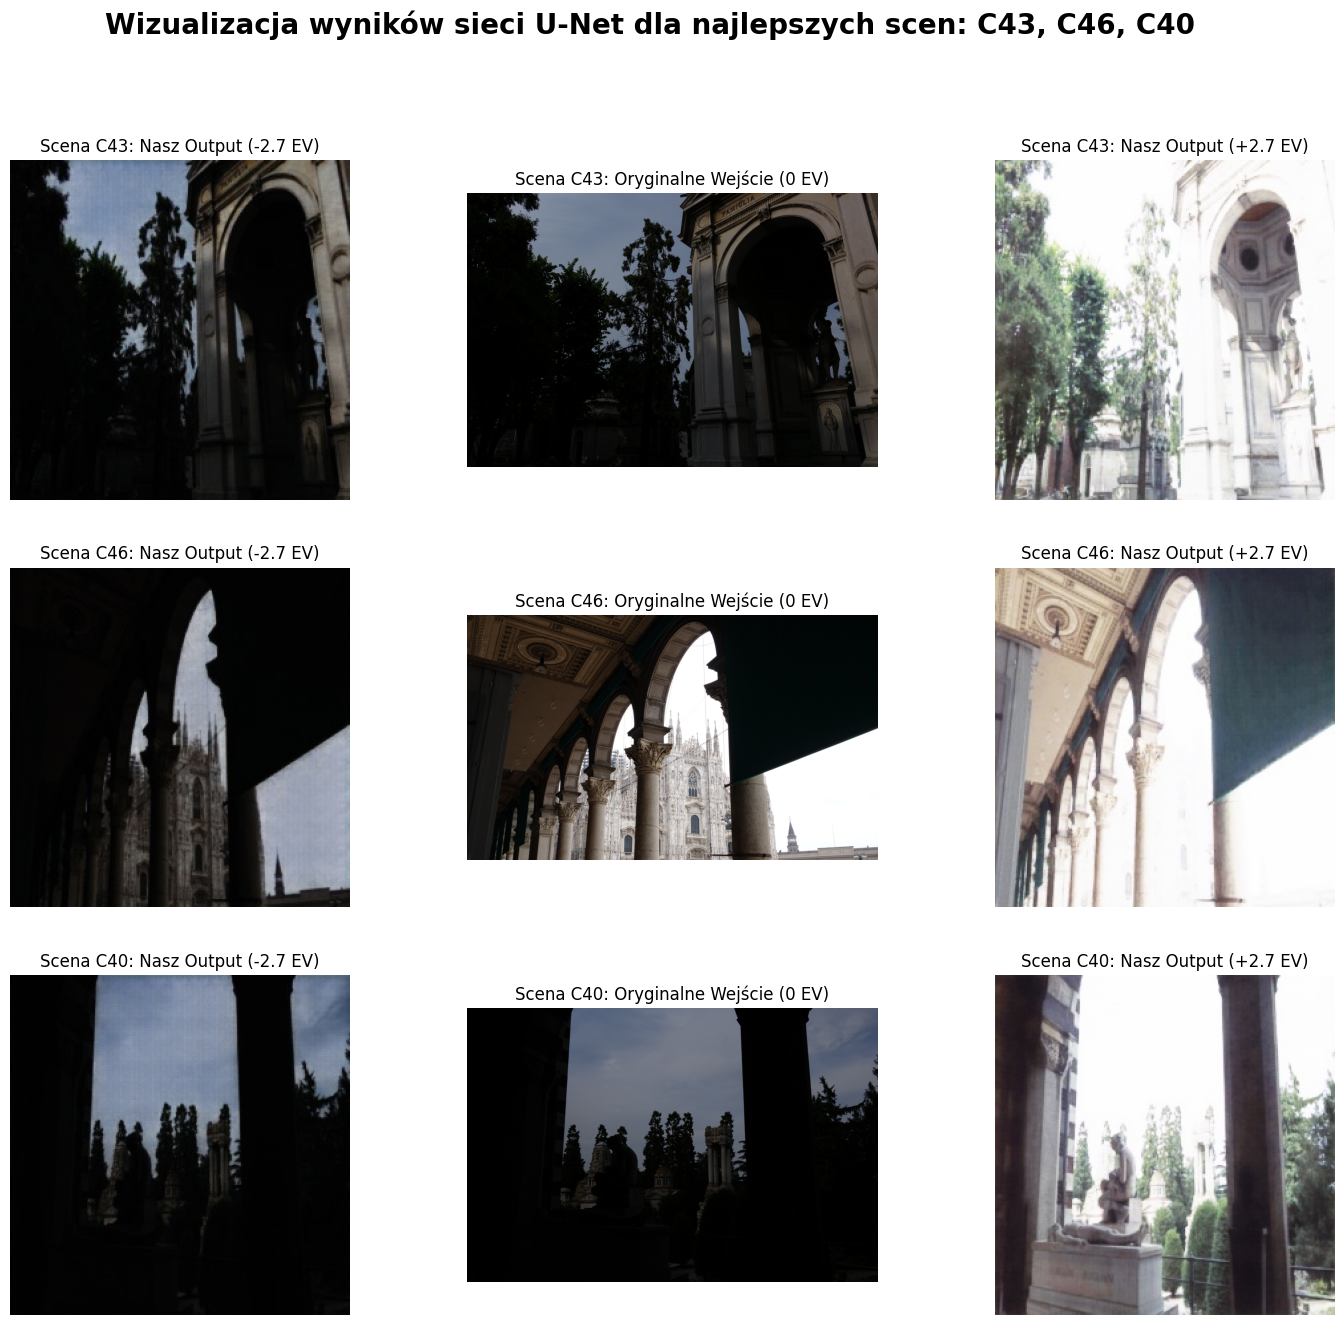

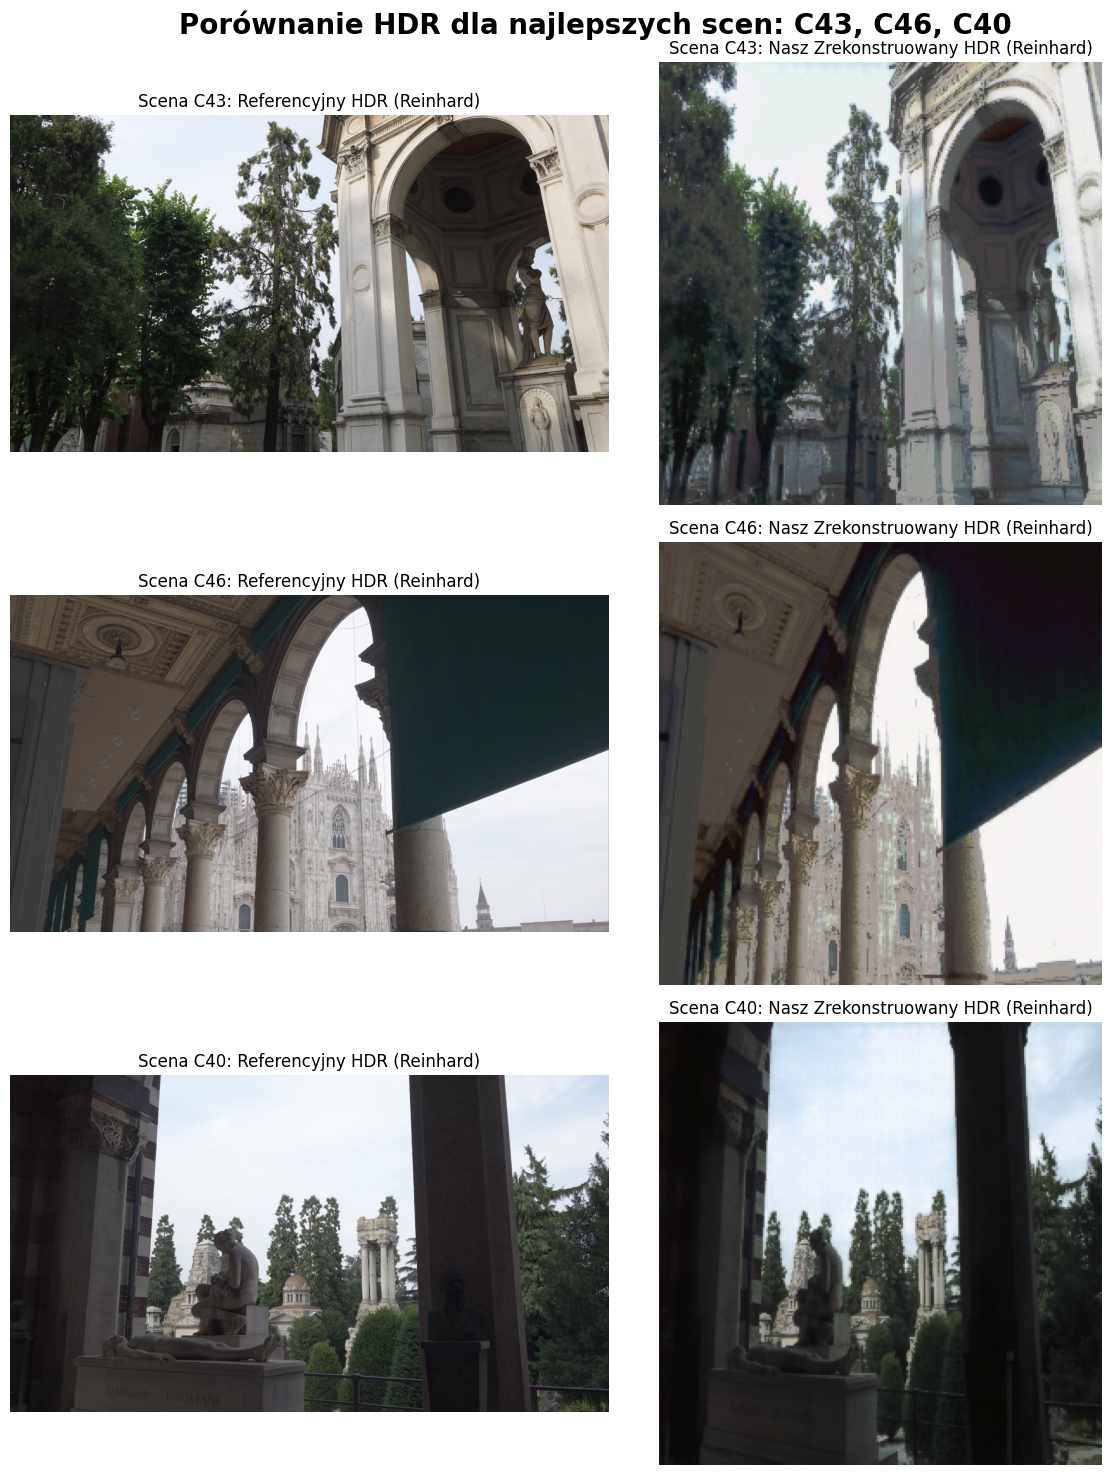

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os
from utils import read_hdr, tone_map_reinhard
from constants import DATASET_ROOT, HDR_ORIGINAL_ROOT, OUTPUT_DIR_PATH

SCENES_TO_VISUALIZE = ["C43", "C46", "C40"]  # Wybrane najlepsze sceny na podstawie średniego PSNR
OUTPUT_DIR_PATH_N = os.path.abspath(OUTPUT_DIR_PATH + "/run_L1_VGG_256x256_E200_LR0.0001")

try:
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    fig.suptitle("Wizualizacja wyników sieci U-Net dla najlepszych scen: C43, C46, C40", fontsize=20, fontweight='bold')
    
    for i, scene in enumerate(SCENES_TO_VISUALIZE):
        ldr_paths = sorted(os.listdir(os.path.join(DATASET_ROOT, scene)))
        ldr_paths = [f for f in ldr_paths if f.lower().endswith('.jpg')]
        img_mid = cv2.cvtColor(cv2.imread(os.path.join(DATASET_ROOT, scene, ldr_paths[len(ldr_paths)//2])), cv2.COLOR_BGR2RGB)
        
        scene_output_dir = os.path.join(OUTPUT_DIR_PATH_N, scene)
        img_under_gen = cv2.cvtColor(cv2.imread(os.path.join(scene_output_dir, "gen_under.jpg")), cv2.COLOR_BGR2RGB)
        img_over_gen = cv2.cvtColor(cv2.imread(os.path.join(scene_output_dir, "gen_over.jpg")), cv2.COLOR_BGR2RGB)
        
        orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{scene}_HDR.hdr")
        if not os.path.exists(orig_hdr_path):
            orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{scene}.hdr")
            
        orig_hdr = read_hdr(orig_hdr_path)
        orig_hdr_tm = tone_map_reinhard(orig_hdr)
        
        gen_hdr_path = os.path.join(scene_output_dir, "gen_hdr.hdr")
        gen_hdr = read_hdr(gen_hdr_path)
        gen_hdr_tm = tone_map_reinhard(gen_hdr)
        
        axes[i, 0].imshow(img_under_gen)
        axes[i, 0].set_title(f"Scena {scene}: Nasz Output (-2.7 EV)", fontsize=12); axes[i, 0].axis('off')
        
        axes[i, 1].imshow(img_mid)
        axes[i, 1].set_title(f"Scena {scene}: Oryginalne Wejście (0 EV)", fontsize=12); axes[i, 1].axis('off')
        
        axes[i, 2].imshow(img_over_gen)
        axes[i, 2].set_title(f"Scena {scene}: Nasz Output (+2.7 EV)", fontsize=12); axes[i, 2].axis('off')
        
    
    fig2, axes2 = plt.subplots(3, 2, figsize=(12, 15))
    fig2.suptitle("Porównanie HDR dla najlepszych scen: C43, C46, C40", fontsize=20, fontweight='bold')
    
    for i, scene in enumerate(SCENES_TO_VISUALIZE):
        scene_output_dir = os.path.join(OUTPUT_DIR_PATH_N, scene)
        
        orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{scene}_HDR.hdr")
        if not os.path.exists(orig_hdr_path):
            orig_hdr_path = os.path.join(HDR_ORIGINAL_ROOT, f"{scene}.hdr")
            
        orig_hdr = read_hdr(orig_hdr_path)
        orig_hdr_tm = tone_map_reinhard(orig_hdr)
        
        gen_hdr_path = os.path.join(scene_output_dir, "gen_hdr.hdr")
        gen_hdr = read_hdr(gen_hdr_path)
        gen_hdr_tm = tone_map_reinhard(gen_hdr)
        
        axes2[i, 0].imshow(orig_hdr_tm)
        axes2[i, 0].set_title(f"Scena {scene}: Referencyjny HDR (Reinhard)", fontsize=12); axes2[i, 0].axis('off')
        
        axes2[i, 1].imshow(gen_hdr_tm)
        axes2[i, 1].set_title(f"Scena {scene}: Nasz Zrekonstruowany HDR (Reinhard)", fontsize=12); axes2[i, 1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    fig.tight_layout()
    plt.show()

except Exception as e:
    print(f"Błąd wizualizacji: {e}")